In [10]:
#-------Set up environment--------
library(dplyr)
library(Seurat)
library(httr)
library(readr)
library(harmony)
library(MAST)
library(unixtools)
library(ggplot2)
library(cowplot)
library(future)
library(ggmin)
library(repr)
library(pheatmap)
set_config(config(ssl_verifypeer = 0L))
ulimit::memory_limit(250000)
setwd("/data/lucy/MacroFibroAtlas/NormMFTIntegration/")
set.tempdir("/data/lucy/tmp/")
options(warn = -1, verbose=FALSE)

soft   hard 
250000    Inf

## Integrate macrophage and fibroblast from synovium, lung, skin and heart. 
In addition, we will also include t-cells to act as extra 'anchors' between the tissues. 

In [11]:
#Read in subsetted macrophage, fibroblast and t-cells from each tissue 
skinMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Skin/skinMFT.rds")
Idents(skinMFT) <- "MFT"
skinMFT$sample <- paste0(skinMFT$paper,"_",skinMFT$sample)
skinMFT <- DietSeurat(skinMFT, assays = c("RNA", "integrated"))
synoMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Synovium/synoMFT.rds")
Idents(synoMFT) <- "MFT"
DefaultAssay(synoMFT) <- "integrated"
synoMFT <- DietSeurat(synoMFT, assays = c("RNA", "integrated"))
lungMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Lung/lungMFT.rds")
Idents(lungMFT) <- "MFT"
lungMFT <- DietSeurat(lungMFT, assays = c("RNA", "integrated"))
heartMFT <- readRDS("/data/lucy/MacroFibroAtlas/Data/Heart/heartMFT.rds")
Idents(heartMFT) <- "MFT"
heartMFT <- DietSeurat(heartMFT, assays = c("RNA", "integrated"))

## How many cells of each type in each tissue atlas?


In [4]:
table(skinMFT$MFT)


Myeloid Stromal T Cells 
   8450   23544   10883 

In [5]:
table(synoMFT$MFT)


Myeloid Stromal T Cells 
  50698   31685   19399 

In [6]:
table(lungMFT$MFT)


Myeloid Stromal T Cells 
  65589    4916   17259 

In [7]:
table(heartMFT$MFT)


Myeloid Stromal T Cells 
  22838   59305   15166 

## Create subset for each tissue with reduced number of cells so all tissues normalized.
   We will also ensure that we have equal number of macrophage and fibroblast.

In [8]:
#Skin
set.seed(111)
skin.macro <- WhichCells(skinMFT, ident="Myeloid")
skin.macro.sub <- sample(x = skin.macro, size = 4500, replace = F)
skin.fibro <- WhichCells(skinMFT, ident="Stromal")
skin.fibro.sub <- sample(x = skin.fibro, size = 4500, replace = F)
skin.tcell <- WhichCells(skinMFT, ident="T Cells")
skin.tcell.sub <- sample(x = skin.tcell, size = 1000, replace = F)
subSkinMFT <- subset(skinMFT, cells=c(skin.macro.sub, skin.fibro.sub, skin.tcell.sub))
saveRDS(subSkinMFT, "subSkinMFT.rds")

In [9]:
#Synovium
syno.macro <- WhichCells(synoMFT, ident="Myeloid")
syno.macro.sub <- sample(x = syno.macro, size = 4500, replace = F)
syno.fibro <- WhichCells(synoMFT, ident="Stromal")
syno.fibro.sub <- sample(x = syno.fibro, size = 4500, replace = F)
syno.tcell <- WhichCells(synoMFT, ident="T Cells")
syno.tcell.sub <- sample(x = syno.tcell, size = 1000, replace = F)
subSynoMFT <- subset(synoMFT, cells=c(syno.macro.sub, syno.fibro.sub, syno.tcell.sub))
saveRDS(subSynoMFT, "subSynoMFT.rds")

In [10]:
#Lung
lung.macro <- WhichCells(lungMFT, ident="Myeloid")
lung.macro.sub <- sample(x = lung.macro, size = 4500, replace = F)
lung.fibro <- WhichCells(lungMFT, ident="Stromal")
lung.fibro.sub <- sample(x = lung.fibro, size = 4500, replace = F)
lung.tcell <- WhichCells(lungMFT, ident="T Cells")
lung.tcell.sub <- sample(x = lung.tcell, size = 1000, replace = F)
subLungMFT <- subset(lungMFT, cells=c(lung.macro.sub, lung.fibro.sub, lung.tcell.sub))
saveRDS(subLungMFT, "subLungMFT.rds")

In [15]:
unique(heartMFT$cell_source)

[1] NA               "Harvard-Nuclei" "Sanger-Nuclei"  "Sanger-Cells"  
[5] "Sanger-CD45"

In [16]:
heartMFT$cell_source[is.na(heartMFT$cell_source)] <- "Wang2020"

In [17]:
unique(heartMFT$cell_source)

[1] "Wang2020"       "Harvard-Nuclei" "Sanger-Nuclei"  "Sanger-Cells"  
[5] "Sanger-CD45"

In [24]:
#Heart
Idents(heartMFT) <- "cell_source"
heartMFTcells <- subset(heartMFT, idents=c("Sanger-Cells","Sanger-CD45","Wang2020"))
Idents(heartMFT) <- "MFT"
Idents(heartMFTcells) <- "MFT"
table(heartMFTcells$MFT)


Myeloid Stromal T Cells 
  11284    3288    9695 

In [25]:
#Heart
heart.macroCells <- WhichCells(heartMFTcells, ident="Myeloid")
heart.macro.subCells <- sample(x = heart.macroCells, size = 4500, replace = F)
heart.fibroCells <- WhichCells(heartMFTcells, ident="Stromal")
#Only 3288 fibroblasts from heart
length(heart.fibroCells)
heart.tcellCells <- WhichCells(heartMFTcells, ident="T Cells")
heart.tcell.subCells <- sample(x = heart.tcellCells, size = 1000, replace = F)
subHeartMFT <- subset(heartMFT, cells=c(heart.macro.subCells,heart.fibroCells,heart.tcell.subCells))
saveRDS(subHeartMFT, "subHeartMFT.rds")

[1] 3288

In [26]:
#Wipe environment to save space and reload tissue subsets of MFs
remove(list = ls())
gc()
subSynoMFT <- readRDS("subSynoMFT.rds")
subSynoMFT$tissue <- "Synovium"
DefaultAssay(subSynoMFT) <- "integrated"
subSkinMFT <- readRDS("subSkinMFT.rds")
subSkinMFT$tissue <- "Skin"
DefaultAssay(subSkinMFT) <- "integrated"
subLungMFT <- readRDS("subLungMFT.rds")
subLungMFT$tissue <- "Lung"
DefaultAssay(subLungMFT) <- "integrated"
subHeartMFT <- readRDS("subHeartMFT.rds")
subHeartMFT$tissue <- "Heart"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,6107835,326.2,12350545,659.6,12350545,659.6
Vcells,10915405,83.3,2780243145,21211.6,3475303574,26514.5


## Visualize the data pre-integration.

Centering and scaling data matrix

10:42:37 UMAP embedding parameters a = 0.9922 b = 1.112

10:42:37 Read 38788 rows and found 30 numeric columns

10:42:37 Using Annoy for neighbor search, n_neighbors = 30

10:42:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*

|

10:42:50 Writing NN index file to temp file /data/lucy/tmp//fileb53119c153c4

10:42:50 Searching Annoy index using 1 thread, search_k = 3000

10:43:03 Annoy recall = 100%

10:43:04 Commencing smooth kNN distance calibration using 1 thread

10:43:07 Initializing from normalized Laplacian + noise

10:43:10 Commencing optimization for 200 epochs, with 1642372 positive edges

10:44:07 Optimization finished



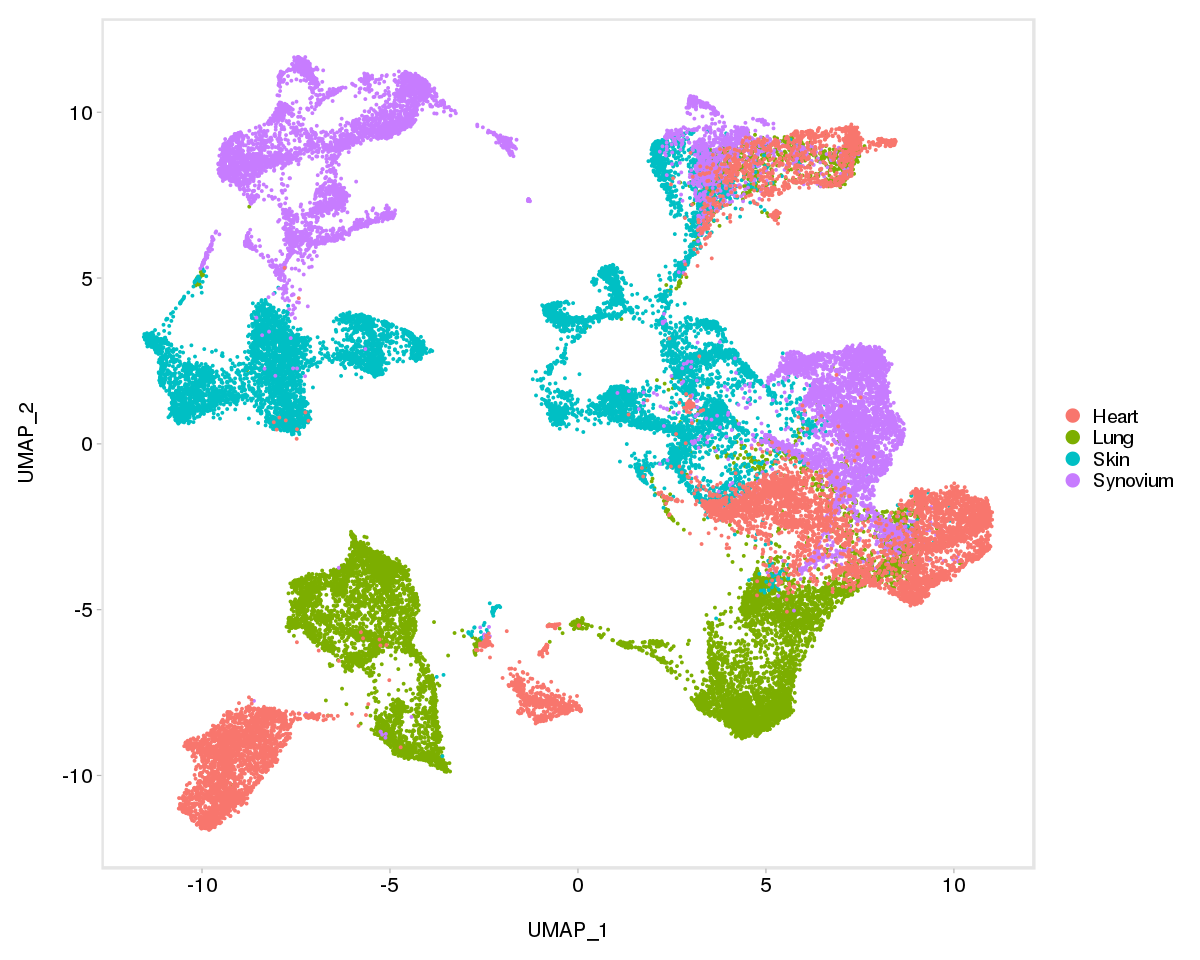

In [27]:
#Merge the data from various tissue to visualize pre-integration
mergedMFTatlas <- merge(x=subLungMFT, y=c(subSkinMFT,subSynoMFT,subHeartMFT), add.cell.ids=c("Lung","Skin","Synovium","Heart"))
DefaultAssay(mergedMFTatlas) <- "RNA"

#Need to remove integrated assay or harmony gets upset
mergedMFTatlas@assays$integrated <- NULL
VariableFeatures(mergedMFTatlas) <- c(VariableFeatures(subLungMFT), VariableFeatures(subSkinMFT), 
                                      VariableFeatures(subSynoMFT), VariableFeatures(subHeartMFT))
mergedMFTatlas <- ScaleData(mergedMFTatlas, features = VariableFeatures(mergedMFTatlas))
mergedMFTatlas <- RunPCA(mergedMFTatlas, npcs = 50, verbose = FALSE)
#Visualize umap pre-integration 
mergedMFTatlas <- RunUMAP(mergedMFTatlas, reduction = "pca", dims = 1:30)
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="tissue") + theme_powerpoint()

In [24]:
DefaultAssay(mergedMFTatlas) <- "RNA"
#Need to remove integrated assay or harmony gets upset
mergedMFTatlas <- RunPCA(mergedMFTatlas, npcs = 50, verbose = FALSE)
#Visualize umap pre-integration 
mergedMFTatlas <- RunUMAP(mergedMFTatlas, reduction = "pca", dims = 1:30)
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="tissue") + theme_powerpoint()

ERROR: Error in PrepDR(object = object, features = features, verbose = verbose): Variable features haven't been set. Run FindVariableFeatures() or provide a vector of feature names.


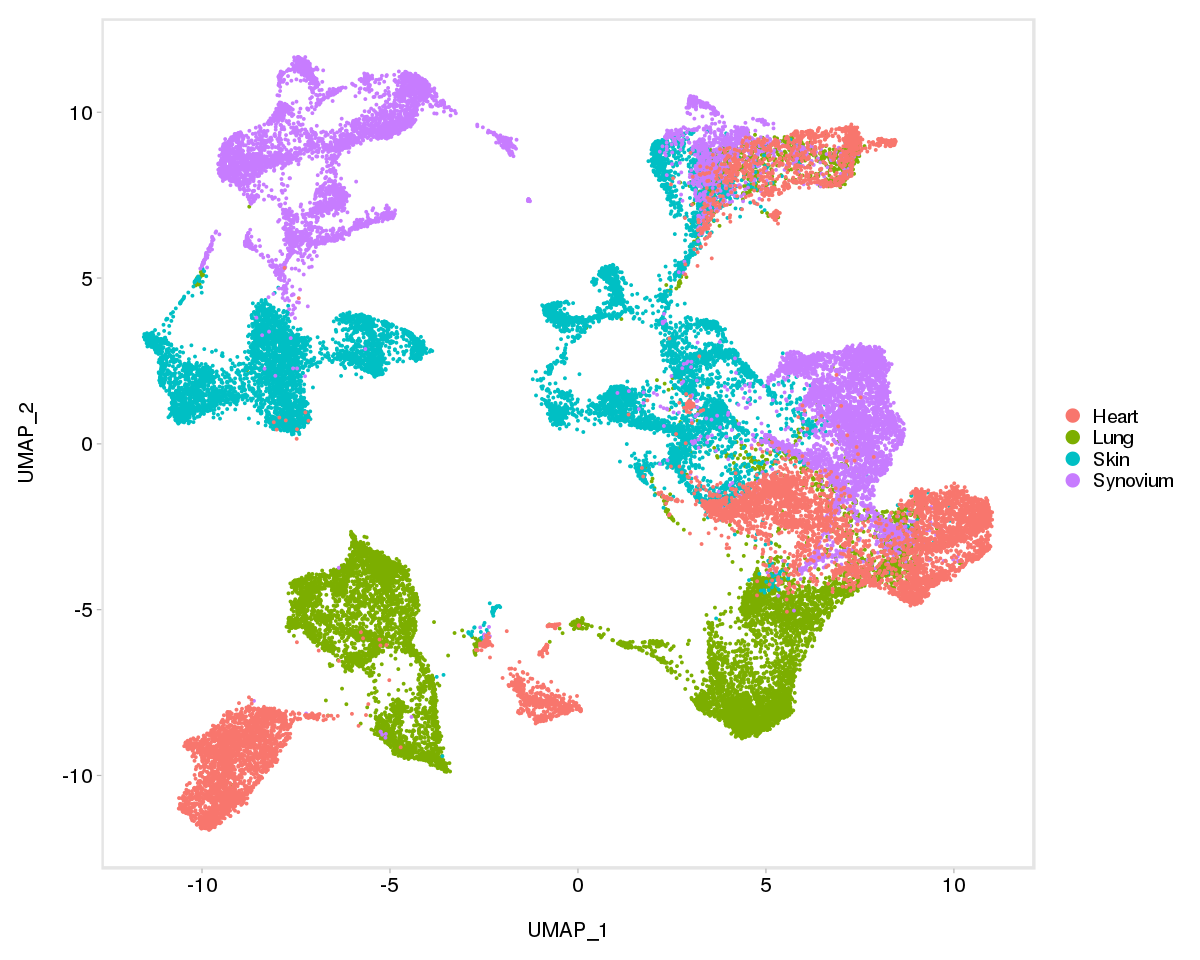

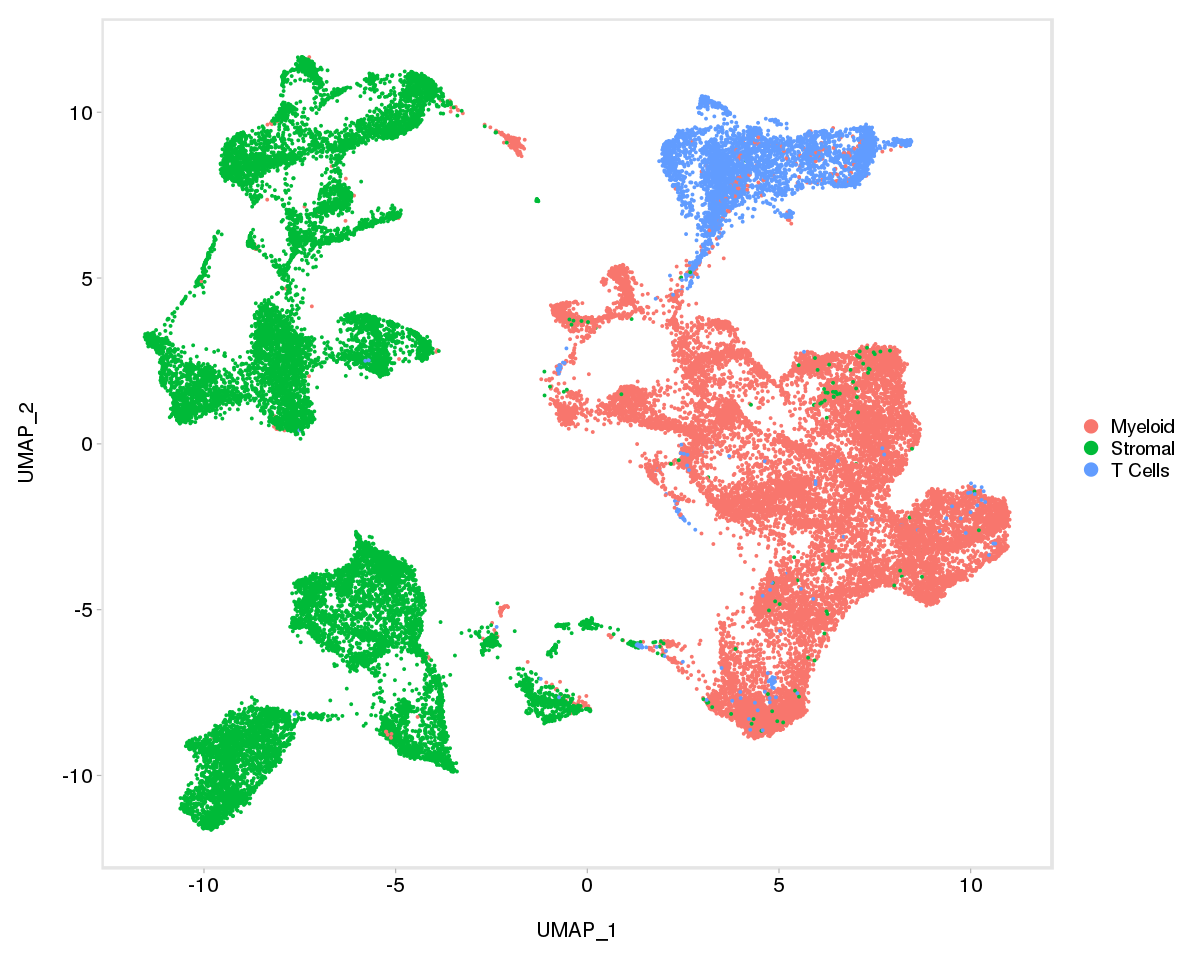

In [12]:
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="tissue") + theme_powerpoint()
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap", group.by="MFT") + theme_powerpoint()

In [29]:
saveRDS(mergedMFTatlas, "mergedMFTatlas.rds")

In [17]:
mergedMFTatlas <- readRDS("/data/lucy/MacroFibroAtlas/NormMFTIntegration/OldAnalyses/oldHeartMFT/mergedMFTatlas.rds")

In [18]:
options(repr.plot.width=10, repr.plot.height=8)
DimPlot(object = mergedMFTatlas, reduction = "umap") + theme_powerpoint()

ERROR: Error in `[[.Seurat`(object, reduction): Cannot find 'umap' in this Seurat object


In [8]:
mergedMFTatlas <- FindNeighbors(mergedMFTatlas, reduction = "pca", dims = 1:30, verbose=FALSE)
mergedMFTatlas <- FindClusters(mergedMFTatlas, res=0.4, verbose = FALSE)

In [30]:
table(mergedMFTatlas$sample)


                    C1                     C2           CER_SynBio23 
                    81                     21                    344 
          CER_SynBio26           CER_SynBio28           CER_SynBio49 
                   683                    431                     73 
          CER_SynBio50                     D1                     D2 
                   228                     59                    181 
                    D4                     D5                 HC0547 
                    61                     16                     79 
                HC0572                 HC0701                 HC0732 
                   135                    180                     49 
       HCAHeart7606896        HCAHeart7656534        HCAHeart7656535 
                    12                     59                      9 
       HCAHeart7656536        HCAHeart7656537        HCAHeart7656538 
                   125                      8                     97 
       HCAHeart7728

In [31]:
#This step was completed by downloading object and running on my local R studio 
#as todata1 does not have SeuratDisk installed
#mergedMFTatlas <- DietSeurat(mergedMFTatlas, scale.data=FALSE)
#mergedMFTatlas <- ScaleData(mergedMFTatlas, features=rownames(mergedMFTatlas))
#mergedMFTatlas <- FindVariableFeatures(mergedMFTatlas, nfeatures=6000)
#saveRDS(mergedMFTatlas, "mergedMFTatlas.rds")
#SaveH5Seurat(mergedMFTatlas, overwrite = TRUE)
#Convert(source="mergedMFTatlas.h5Seurat", to = "anndata", dest = "mergedMFTatlas.h5ad")